# DistilBERT

Este notebook entrena `distilbert-base-uncased` para clasificar las reseñas de Kaggle como `negative` o `positive`. Después calcula atribuciones por token con Integrated Gradients para mostrar qué palabras contribuyen más a la decisión.

Las atribuciones indican la influencia del modelo sobre esta entrada; no son una explicación causal ni garantizan que el modelo haya razonado como una persona.

In [31]:
from importlib.util import find_spec

required_packages = ['transformers', 'torch', 'captum', 'sklearn', 'pandas']
missing_packages = [package for package in required_packages if find_spec(package) is None]
if missing_packages:
    raise ImportError(f'Faltan dependencias. Ejecuta `pip install -r requirements.txt`: {missing_packages}')
print('Dependencias disponibles.')

Dependencias disponibles.


In [ ]:
from pathlib import Path
import copy
import random
from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from captum.attr import LayerIntegratedGradients
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, f1_score
from torch.optim import AdamW
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer, get_linear_schedule_with_warmup

RANDOM_STATE = 42
MODEL_NAME = 'distilbert-base-uncased'
MAX_LENGTH = 192
SAMPLE_SIZE = 8000
BATCH_SIZE = 16
EPOCHS = 10
PATIENCE = 2

if not torch.cuda.is_available():
    raise RuntimeError('CUDA no está disponible. Instala requirements.txt y reinicia el kernel de Jupyter.')
DEVICE = torch.device('cuda')
print(f'Dispositivo GPU: {torch.cuda.get_device_name(0)}')

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)

Dispositivo GPU: NVIDIA GeForce RTX 3060 Laptop GPU


## 1. Cargar el dataset limpio

Este notebook reutiliza `cleaned_reviews.csv`, generado previamente por los notebooks 02 y 03. Se esperan las columnas `text` y `label`, con etiquetas `negative`/`positive` que se convierten a `0`/`1` para PyTorch.

In [ ]:
DATA_PATH = Path('cleaned_reviews.csv')
if not DATA_PATH.exists():
    raise FileNotFoundError('No se encontró cleaned_reviews.csv. Ejecuta primero el notebook 02 o 03.')

reviews = pd.read_csv(DATA_PATH)
required_columns = {'text', 'label'}
missing_columns = required_columns.difference(reviews.columns)
if missing_columns:
    raise ValueError(f'Faltan columnas en cleaned_reviews.csv: {sorted(missing_columns)}')

reviews = reviews[['text', 'label']].dropna().drop_duplicates(subset='text').reset_index(drop=True)
label_map = {'negative': 0, 'positive': 1, '0': 0, '1': 1}
reviews['label'] = reviews['label'].astype(str).str.strip().str.lower().map(label_map)
reviews = reviews.dropna(subset=['label']).copy()
reviews['label'] = reviews['label'].astype(int)
if not reviews['label'].isin([0, 1]).all():
    raise ValueError('La columna label debe contener negative/positive o 0/1.')

if SAMPLE_SIZE and len(reviews) > SAMPLE_SIZE:
    reviews, _ = train_test_split(
        reviews,
        train_size=SAMPLE_SIZE,
        stratify=reviews['label'],
        random_state=RANDOM_STATE,
    )

print(f'Dataset cargado: {len(reviews):,} reseñas')
reviews['label'].value_counts().sort_index()

Dataset cargado: 8,000 reseÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â±as


label
0    3991
1    4009
Name: count, dtype: int64

## 2. Tokenizacion y fine-tuning ligero

In [34]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    reviews['text'].tolist(), reviews['label'].tolist(), test_size=0.2,
    random_state=RANDOM_STATE, stratify=reviews['label'].tolist()
)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_texts, train_labels, test_size=0.2,
    random_state=RANDOM_STATE, stratify=train_labels
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(DEVICE)


def encode(texts, labels):
    encoded = tokenizer(texts, truncation=True, padding='max_length', max_length=MAX_LENGTH, return_tensors='pt')
    return TensorDataset(encoded['input_ids'], encoded['attention_mask'], torch.tensor(labels, dtype=torch.long))


train_loader = DataLoader(encode(train_texts, train_labels), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(encode(val_texts, val_labels), batch_size=BATCH_SIZE)
test_loader = DataLoader(encode(test_texts, test_labels), batch_size=BATCH_SIZE)
optimizer = AdamW(model.parameters(), lr=1.5e-5, weight_decay=0.01)
total_steps = EPOCHS * len(train_loader)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=max(1, total_steps // 10),
    num_training_steps=total_steps,
)

history = []
best_state = None
best_val_f1 = -1.0
epochs_without_improvement = 0

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    for input_ids, attention_mask, labels in train_loader:
        input_ids = input_ids.to(DEVICE)
        attention_mask = attention_mask.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        output = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        output.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        train_loss += output.loss.item()

    model.eval()
    val_loss = 0.0
    val_predictions, val_targets = [], []
    with torch.no_grad():
        for input_ids, attention_mask, labels in val_loader:
            input_ids = input_ids.to(DEVICE)
            attention_mask = attention_mask.to(DEVICE)
            labels = labels.to(DEVICE)
            output = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            val_loss += output.loss.item()
            val_predictions.extend(output.logits.argmax(dim=1).cpu().tolist())
            val_targets.extend(labels.cpu().tolist())

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)
    val_accuracy = accuracy_score(val_targets, val_predictions)
    val_f1 = f1_score(val_targets, val_predictions, average='macro')
    history.append({'epoch': epoch + 1, 'train_loss': train_loss, 'val_loss': val_loss, 'val_accuracy': val_accuracy, 'val_f1': val_f1})
    print(f'Epoch {epoch + 1}: train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_accuracy={val_accuracy:.3f} | val_f1={val_f1:.3f}')

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print(f'Early stopping en la epoca {epoch + 1}.')
            break

model.load_state_dict(best_state)
history = pd.DataFrame(history)
history

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1: train_loss=0.5438 | val_loss=0.3097 | val_accuracy=0.868 | val_f1=0.868
Epoch 2: train_loss=0.2851 | val_loss=0.2977 | val_accuracy=0.881 | val_f1=0.881
Epoch 3: train_loss=0.1775 | val_loss=0.4220 | val_accuracy=0.874 | val_f1=0.874
Epoch 4: train_loss=0.1041 | val_loss=0.5167 | val_accuracy=0.880 | val_f1=0.880
Early stopping en la epoca 4.


,epoch,train_loss,val_loss,val_accuracy,val_f1
0,1,0.543833,0.309744,0.867969,0.867967
1,2,0.285140,0.297686,0.881250,0.880933
2,3,0.177481,0.421978,0.874219,0.873894
3,4,0.104061,0.516694,0.879687,0.879686


Mejor val_f1: 0.881
Accuracy test: 0.865
F1 macro test: 0.865
              precision    recall  f1-score   support

    negative       0.90      0.82      0.86       798
    positive       0.83      0.91      0.87       802

    accuracy                           0.86      1600
   macro avg       0.87      0.86      0.86      1600
weighted avg       0.87      0.86      0.86      1600



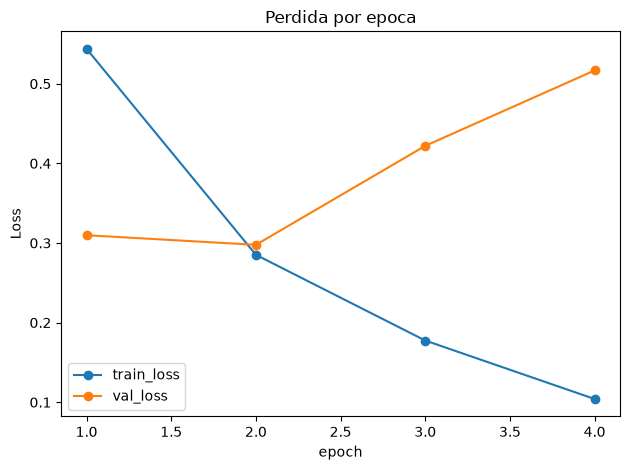

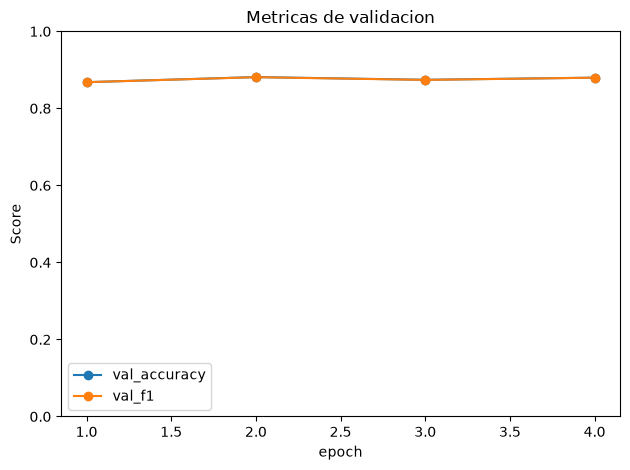

In [35]:
model.eval()
all_predictions, all_targets = [], []
with torch.no_grad():
    for input_ids, attention_mask, labels in test_loader:
        logits = model(input_ids=input_ids.to(DEVICE), attention_mask=attention_mask.to(DEVICE)).logits
        all_predictions.extend(logits.argmax(dim=1).cpu().tolist())
        all_targets.extend(labels.tolist())

print(f'Mejor val_f1: {best_val_f1:.3f}')
print(f'Accuracy test: {accuracy_score(all_targets, all_predictions):.3f}')
print(f'F1 macro test: {f1_score(all_targets, all_predictions, average="macro"):.3f}')
print(classification_report(all_targets, all_predictions, target_names=['negative', 'positive'], zero_division=0))

history.plot(x='epoch', y=['train_loss', 'val_loss'], marker='o', title='Perdida por epoca')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()

history.plot(x='epoch', y=['val_accuracy', 'val_f1'], marker='o', title='Metricas de validacion')
plt.ylabel('Score')
plt.ylim(0.0, 1.0)
plt.tight_layout()
plt.show()

## 3. Explicacion por token con Integrated Gradients

In [36]:
def predict_review(text):
    encoded = tokenizer(text, truncation=True, padding='max_length', max_length=MAX_LENGTH, return_tensors='pt')
    encoded = {key: value.to(DEVICE) for key, value in encoded.items()}
    with torch.no_grad():
        probabilities = model(**encoded).logits.softmax(dim=-1)[0]
    predicted_class = int(probabilities.argmax())
    return encoded, predicted_class, probabilities.cpu().numpy()


def explain_review(text, steps=32, top_k=12):
    encoded, predicted_class, probabilities = predict_review(text)
    input_ids = encoded['input_ids']
    attention_mask = encoded['attention_mask']

    def forward_func(ids, mask):
        return model(input_ids=ids, attention_mask=mask).logits

    attribution = LayerIntegratedGradients(forward_func, model.distilbert.embeddings)
    token_attributions, convergence_delta = attribution.attribute(
        inputs=input_ids,
        additional_forward_args=(attention_mask,),
        target=1,
        n_steps=steps,
        return_convergence_delta=True,
    )
    scores = token_attributions.sum(dim=-1).squeeze(0)
    scores = scores / (scores.abs().max() + 1e-8)
    tokens = tokenizer.convert_ids_to_tokens(input_ids.squeeze(0))
    visible = [
        (token, float(score))
        for token, score, mask in zip(tokens, scores.detach().cpu(), attention_mask.squeeze(0))
        if int(mask) == 1 and token not in {'[CLS]', '[SEP]', '[PAD]'}
    ]
    visible = sorted(visible, key=lambda item: abs(item[1]), reverse=True)[:top_k]
    explanation = pd.DataFrame(visible, columns=['token', 'attribution'])
    explanation['evidence'] = explanation['attribution'].map(
        lambda value: 'supports positive' if value > 0 else 'supports negative'
    )
    explanation = explanation.sort_values('attribution')
    label = 'positive' if predicted_class == 1 else 'negative'
    delta = float(convergence_delta.abs().mean())
    print(f'Prediccion: {label} | P(negative)={probabilities[0]:.3f} | P(positive)={probabilities[1]:.3f}')
    print(f'Delta de convergencia: {delta:.6f}')
    if delta > 0.1:
        print('Advertencia: la convergencia es baja; interpreta las atribuciones con cautela.')
    return explanation


positive_example: The acting was excellent and the story was deeply moving.
Prediccion: positive | P(negative)=0.018 | P(positive)=0.982
Delta de convergencia: 0.153454
Advertencia: la convergencia es baja; interpreta las atribuciones con cautela.


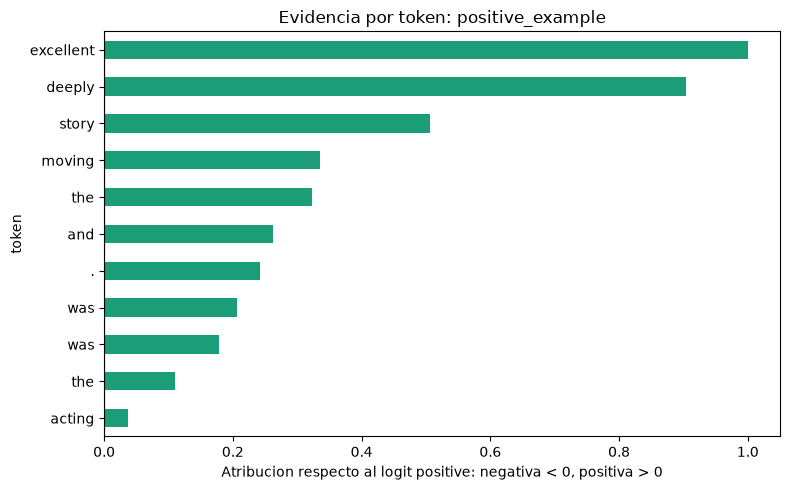

,token,attribution,evidence
10,acting,0.037769,supports positive
9,the,0.110313,supports positive
8,was,0.177915,supports positive
7,was,0.207032,supports positive
6,.,0.241468,supports positive
5,and,0.262384,supports positive
4,the,0.322201,supports positive
3,moving,0.334873,supports positive
2,story,0.506234,supports positive
1,deeply,0.904186,supports positive



negative_example: The acting was terrible, the story was boring, and I hated it.
Prediccion: negative | P(negative)=0.981 | P(positive)=0.019
Delta de convergencia: 0.214189
Advertencia: la convergencia es baja; interpreta las atribuciones con cautela.


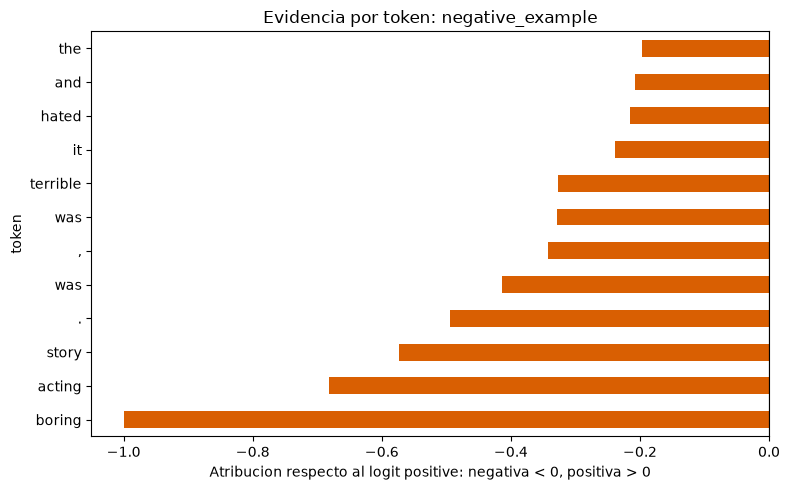

,token,attribution,evidence
0,boring,-1.000000,supports negative
1,acting,-0.682399,supports negative
2,story,-0.573016,supports negative
3,.,-0.493872,supports negative
4,was,-0.414066,supports negative
5,",",-0.342587,supports negative
6,was,-0.329186,supports negative
7,terrible,-0.327533,supports negative
8,it,-0.238239,supports negative
9,hated,-0.214989,supports negative


In [37]:
examples = {
    'positive_example': 'The acting was excellent and the story was deeply moving.',
    'negative_example': 'The acting was terrible, the story was boring, and I hated it.',
}

for name, text in examples.items():
    print(f'\n{name}: {text}')
    example_explanation = explain_review(text)
    example_explanation.plot.barh(
        x='token',
        y='attribution',
        color=['#d95f02' if value < 0 else '#1b9e77' for value in example_explanation['attribution']],
        legend=False,
        figsize=(8, 5),
        title=f'Evidencia por token: {name}',
    )
    plt.axvline(0, color='black', linewidth=0.8)
    plt.xlabel('Atribucion respecto al logit positive: negativa < 0, positiva > 0')
    plt.tight_layout()
    plt.show()
    display(example_explanation)

## Interpretación, comparación y limitaciones

En este proyecto, el modelo clásico optimizado es la mejor opción práctica: obtuvo `0.916` de accuracy en test, frente a aproximadamente `0.865` de DistilBERT. DistilBERT aporta una representación contextual y explicaciones por token, pero necesita GPU, tarda más en entrenar y no superó al TF-IDF con `LinearSVC`.

El entrenamiento mostró overfitting: la pérdida de entrenamiento siguió bajando mientras la validación empeoraba después de las primeras épocas. Por eso se usa validación, early stopping, gradient clipping, weight decay y selección del mejor checkpoint por F1 macro.

Integrated Gradients indica qué tokens modifican el logit de `positive`; no demuestra causalidad ni revela una cadena de razonamiento humana. Los sub-tokens pueden estar fragmentados y las atribuciones pueden ser inestables.

## Conclusiones

Usa `03_model_improvement.ipynb` para producción ligera y `04_distilbert_explainability.ipynb` cuando necesites explorar contexto y atribuciones. Antes de desplegar, repite la evaluación con varias semillas y mide el rendimiento fuera del dominio cinematográfico.

## Conclusiones

En los resultados observados, el modelo TF-IDF con `LinearSVC` optimizado obtuvo `0.916` de accuracy y superó a DistilBERT, que obtuvo aproximadamente `0.865`. Por tanto, usa el modelo clásico para producción ligera y DistilBERT cuando necesites estudiar contexto y atribuciones por token.

Las conclusiones deben confirmarse con varias semillas, particiones consistentes, intervalos de confianza y pruebas fuera del dominio cinematográfico. Integrated Gradients aporta indicios de influencia del modelo, no explicaciones causales.